# Lecture 21 — Transformers and Self-Attention

**CMU 10-414/714, Deep Learning Systems (lecture by Zico Kolter)**
Companion notebook · Sangram Lembe

The lecture's claims about self-attention, each checked numerically:

1. a temporal convolution only sees as far back as its depth, kernel and dilation allow
2. self-attention mixes the **whole** sequence in one layer, with no extra parameters as $T$ grows
3. it is **permutation equivariant** — it has no idea of order on its own
4. a causal mask stops outputs depending on the future; positional encodings restore order
5. the price: a $T\times T$ matrix, so cost grows with $T^2$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)

def softmax(Z):
    Z = np.exp(Z - Z.max(axis=-1, keepdims=True))
    return Z / Z.sum(axis=-1, keepdims=True)

## 1. How far back can a temporal convolution see?

A causal convolution at time $t$ only looks at times $\le t$. Its **receptive field** — how many past inputs
can affect one output — is set by the architecture:

In [2]:
def receptive_field(depth, kernel, dilation_growth=1):
    field, dil = 1, 1
    for _ in range(depth):
        field += (kernel - 1) * dil
        dil *= dilation_growth
    return field

print(f"{'layers':>7}{'kernel 2':>10}{'kernel 3':>10}{'k=2, dilation doubling':>25}")
for L in (1, 2, 4, 8, 10):
    print(f"{L:>7}{receptive_field(L, 2):>10}{receptive_field(L, 3):>10}{receptive_field(L, 2, 2):>25}")

 layers  kernel 2  kernel 3   k=2, dilation doubling
      1         2         3                        2
      2         3         5                        4
      4         5         9                       16
      8         9        17                      256
     10        11        21                     1024


Plain convolutions grow the field by one step per layer. Bigger kernels cost more weights; dilation grows it
exponentially but skips inputs. Self-attention avoids the trade-off entirely.

## 2. Self-attention from scratch

$$\mathrm{SelfAttention}(K, Q, V) = \mathrm{softmax}\!\left(\frac{KQ^{\mathsf T}}{\sqrt d}\right) V,
\qquad K = XW_K,\; Q = XW_Q,\; V = XW_V$$

In [3]:
def self_attention(X, W_K, W_Q, W_V, mask=None):
    K, Q, V = X @ W_K, X @ W_Q, X @ W_V                       # each row comes from one time step
    scores = K @ Q.T / np.sqrt(X.shape[1])                     # T x T
    if mask is not None:
        scores = scores + mask
    A = softmax(scores)                                         # each row: weights summing to 1
    return A @ V, A

T, d = 6, 4
X = rng.normal(size=(T, d))
W_K, W_Q, W_V = (rng.normal(size=(d, d)) for _ in range(3))
Y, A = self_attention(X, W_K, W_Q, W_V)
print("attention matrix:", A.shape, "  rows sum to 1:", np.allclose(A.sum(1), 1))
print("output row 0 == weighted mix of ALL value rows:", np.allclose(Y[0], A[0] @ (X @ W_V)))

attention matrix: (6, 6)   rows sum to 1: True
output row 0 == weighted mix of ALL value rows: True


Every output row is a weighted average of **every** value row — the whole sequence mixed in one layer. And
the parameters ($W_K, W_Q, W_V$) are $d\times d$ whatever the length:

In [4]:
for T_ in (10, 1000):
    Y_, _ = self_attention(rng.normal(size=(T_, d)), W_K, W_Q, W_V)
    print(f"T = {T_:>5}: output {Y_.shape}, parameters still {3 * d * d}")

T =    10: output (10, 4), parameters still 48
T =  1000: output (1000, 4), parameters still 48


## 3. Permutation equivariance

Shuffle the input rows and the output rows are shuffled the same way — nothing else changes. Attention by
itself cannot tell "dog bites man" from "man bites dog".

In [5]:
perm = rng.permutation(T)
Y_perm, _ = self_attention(X[perm], W_K, W_Q, W_V)
print("attention(shuffled X) == shuffled attention(X):", np.allclose(Y_perm, Y[perm]))

attention(shuffled X) == shuffled attention(X): True


## 4. Two fixes for time series

### The causal mask

Add $-\infty$ above the diagonal before the softmax, so time $t$ puts zero weight on later times. Test it by
changing a *future* input and checking that earlier outputs do not move:

In [6]:
mask = np.triu(np.full((T, T), -np.inf), k=1)
Yc, Ac = self_attention(X, W_K, W_Q, W_V, mask)
X2 = X.copy(); X2[4] += 10.0                                   # change the input at t = 4
Yc2, _ = self_attention(X2, W_K, W_Q, W_V, mask)
print("weights above the diagonal all zero:", np.allclose(np.triu(Ac, 1), 0))
print("outputs t=0..3 unchanged by the future:", np.allclose(Yc[:4], Yc2[:4]))
print("output t=4 changed:", not np.allclose(Yc[4], Yc2[4]))

weights above the diagonal all zero: True
outputs t=0..3 unchanged by the future: True
output t=4 changed: True


### Positional encodings

Add a fixed pattern of sines and cosines at different frequencies, so each position has its own fingerprint.
Then shuffling is no longer harmless:

with positions, shuffling still just shuffles the output: False


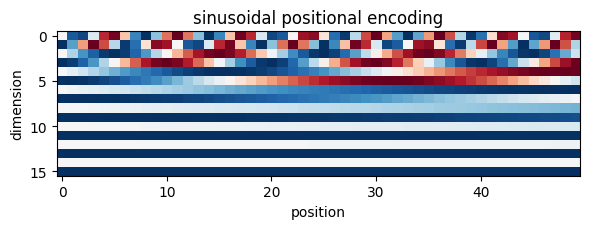

In [7]:
def positional_encoding(T, d):
    pos = np.arange(T)[:, None]
    freq = 1.0 / (10000 ** (np.arange(0, d, 2) / d))
    P = np.zeros((T, d))
    P[:, 0::2], P[:, 1::2] = np.sin(pos * freq), np.cos(pos * freq)
    return P

P = positional_encoding(T, d)
Yp, _ = self_attention(X + P, W_K, W_Q, W_V)
Yp_perm, _ = self_attention(X[perm] + P, W_K, W_Q, W_V)
print("with positions, shuffling still just shuffles the output:", np.allclose(Yp_perm, Yp[perm]))

plt.figure(figsize=(6, 2.4))
plt.imshow(positional_encoding(50, 16).T, aspect="auto", cmap="RdBu")
plt.xlabel("position"); plt.ylabel("dimension"); plt.title("sinusoidal positional encoding")
plt.tight_layout(); plt.show()

## 5. The transformer block

Attention mixes across time; then a small two-layer network is applied to each row separately. Both sit
inside residual connections with layer norm:

$$\tilde Z = \mathrm{LayerNorm}(Z + \mathrm{SelfAttention}(Z)), \qquad
Z_{\text{next}} = \mathrm{LayerNorm}(\tilde Z + \mathrm{ReLU}(\tilde Z W_1) W_2)$$

In [8]:
def layer_norm(Z, eps=1e-5):
    return (Z - Z.mean(-1, keepdims=True)) / np.sqrt(Z.var(-1, keepdims=True) + eps)

def transformer_block(Z, W_K, W_Q, W_V, W1, W2, mask=None):
    Zt = layer_norm(Z + self_attention(Z, W_K, W_Q, W_V, mask)[0])
    return layer_norm(Zt + np.maximum(0, Zt @ W1) @ W2)

W1, W2 = rng.normal(size=(d, 16)), rng.normal(size=(16, d))
out = transformer_block(X, W_K, W_Q, W_V, W1, W2, mask)
print("block maps", X.shape, "->", out.shape)

block maps (6, 4) -> (6, 4)


## 6. The price: $T^2$

The attention matrix has one entry per pair of positions. Memory for it alone, at 4 bytes per number:

In [9]:
for T_ in (512, 4096, 32768):
    print(f"T = {T_:>6}: attention matrix {T_*T_:>14,} entries = {T_*T_*4/1e9:7.3f} GB per head")

pixels, patches = 224 * 224, (224 // 16) ** 2
print(f"\na 224x224 image: {pixels:,} pixels as tokens, or {patches} tokens as 16x16 patches")
print(f"attention entries: {pixels**2:,} vs {patches**2:,}")

T =    512: attention matrix        262,144 entries =   0.001 GB per head
T =   4096: attention matrix     16,777,216 entries =   0.067 GB per head
T =  32768: attention matrix  1,073,741,824 entries =   4.295 GB per head

a 224x224 image: 50,176 pixels as tokens, or 196 tokens as 16x16 patches
attention entries: 2,517,630,976 vs 38,416


That is why vision transformers group pixels into patches: 50,176 pixels would need about 2.5 billion
attention entries; 196 patches need 38,416.

## Summary

- A causal convolution's reach grows by one step per layer; dilation trades coverage for gaps.
- Self-attention mixes every position in one layer, with $3d^2$ parameters at any length.
- On its own it is permutation equivariant — verified — so order must be added back.
- A causal mask made earlier outputs blind to a changed future input; positional encodings broke the
  permutation symmetry.
- The cost is a $T\times T$ matrix: 4 GB per head at $T = 32{,}768$.